In [9]:
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np


def validate_results(results):
    for name, folds in results.items():
        for fold, ns in folds.items():
            for n, sims in ns.items():
                for sim, content in sims.items():
                    assert "true" in content
                    assert "pred" in content
    print("Result schema validated")


with open("./results/benchmarks/convnext_lab2.pkl", "rb") as f:
    results = pickle.load(f)

validate_results(results)

Result schema validated


In [10]:
def infer_axes(results):
    name = next(iter(results))
    fold = next(iter(results[name]))
    n = next(iter(results[name][fold]))
    sim = next(iter(results[name][fold][n]))
    k = next(iter(results[name][fold][n][sim]["pred"]))
    setup = next(iter(results[name][fold][n][sim]["pred"][k]))
    return name, fold, n, sim, k, setup

def create_coder(sub, sim, setups, k):
    if not isinstance(setups, list):
        setups = [setups]
        
    # collect all labels
    labels = [sub[sim]["true"]]
    for setup in setups:
        labels.append(sub[sim]["pred"][k][setup])

    all_labels = np.unique(np.concatenate(labels))
    return LabelEncoder().fit(all_labels)

name0, fold0, n0, sim0, k0, setup0 = infer_axes(results)
NAMES = list(results.keys())
FOLDS = list(results[name0].keys())
N = list(results[name0][fold0].keys())
SIMS = list(results[name0][fold0][n0].keys())
K = list(results[name0][fold0][n0][sim0]["pred"].keys())
SETUPS = list(results[name0][fold0][n0][sim0]["pred"][k0].keys())


def aggregate_metrics(results, name, folds, sims, setups, n, k):
    metrics = {setup: [] for setup in setups}

    for fold in folds:
        sub = results[name][fold][n]
        for sim in sims:
            coder = create_coder(sub, sim, setups, k)
            true = coder.transform(sub[sim]["true"])
            for setup in setups:
                pred = coder.transform(sub[sim]["pred"][k][setup])
                acc = accuracy_score(true, pred)
                prec, rec, f1, _ = precision_recall_fscore_support(true, pred, average="macro", warn_for=[])
                metrics[setup].append((acc, prec, rec, f1))

    return {
        setup: {
            "mean": np.mean(vals, axis=0),
            "std": np.std(vals, axis=0),
        }
        for setup, vals in metrics.items()
    }


def print_markdown_table(stats):
    print("|   Setup   |      Acc     |     Prec     |      Rec     |      F1      |")
    print("|-----|-----| ------------ | ------------ | ------------ | ------------ |")
    # Pre-compute column widths
    all_parts = [setup.split(" - ") for setup in stats]
    col_widths = [max(len(parts[i]) for parts in all_parts) for i in range(max(len(p) for p in all_parts))]

    for setup, s in stats.items():
        row = [
            f"{m * 100:.2f} ± {d * 100:.2f}" 
            for m, d in zip(s["mean"], s["std"])
        ]
        
        parts = setup.split(" - ")
        padded = " | ".join(p.ljust(col_widths[i]) for i, p in enumerate(parts))
        print(f"| {padded} | " + " | ".join(row) + " |")


def print_latex_acc(stats):
    print("% LaTeX table for accuracy only")
    for setup, s in stats.items():
        acc_m, acc_s = s["mean"][0] * 100, s["std"][0] * 100
        g, q = (setup.split(" - ") + [""])[:2]
        print(f"{g} & {q} & {acc_m:.2f}$\\pm${acc_s:.2f}\\% \\\\")

In [11]:
show_latex = False
n = 16  
k = 3
folds = FOLDS[:]    # <- give fold(s) as a list
sims = SIMS[:]      # <- give sim(s) as a list
setups = SETUPS[:]  # <- give sim(s) as a list
metrics = {}

# Define readable metric names for the header
metric_names = ["Acc", "Prec", "Rec", "F1"]

for name in NAMES:
    print(f"### {name}\n")

    stats = aggregate_metrics(
        results=results,
        name=name,
        folds=folds,
        sims=sims,
        setups=setups,
        n=n,
        k=k,
    )

    metrics[name] = stats
    # Markdown table
    print_markdown_table(stats)
    print()

    # Optional LaTeX
    if show_latex:
        print_latex_acc(stats)
        print()


### convnext_femto_cnn_clip_512_LAB

|   Setup   |      Acc     |     Prec     |      Rec     |      F1      |
|-----|-----| ------------ | ------------ | ------------ | ------------ |
| I   | I   | 89.88 ± 2.90 | 89.41 ± 2.99 | 89.48 ± 2.96 | 89.27 ± 3.04 |
| I   | P   | 91.55 ± 1.15 | 91.20 ± 1.22 | 91.15 ± 1.23 | 90.93 ± 1.25 |
| I   | I+P | 92.02 ± 2.17 | 91.64 ± 2.28 | 91.70 ± 2.23 | 91.51 ± 2.30 |
| P   | I   | 90.05 ± 2.11 | 89.64 ± 2.19 | 89.72 ± 2.19 | 89.50 ± 2.21 |
| P   | P   | 93.96 ± 0.61 | 93.55 ± 0.66 | 93.57 ± 0.65 | 93.46 ± 0.66 |
| P   | I+P | 94.51 ± 0.71 | 94.14 ± 0.75 | 94.17 ± 0.75 | 94.07 ± 0.77 |
| I+P | I   | 89.94 ± 2.87 | 89.47 ± 2.96 | 89.54 ± 2.94 | 89.34 ± 3.01 |
| I+P | P   | 94.00 ± 0.61 | 93.59 ± 0.65 | 93.61 ± 0.65 | 93.51 ± 0.66 |
| I+P | I+P | 94.89 ± 0.83 | 94.58 ± 0.90 | 94.62 ± 0.87 | 94.51 ± 0.90 |

### convnext_femto_transformer_clip_512_LAB

|   Setup   |      Acc     |     Prec     |      Rec     |      F1      |
|-----|-----| ------------ | 

### Visualize mean and std for each N

convnext_femto_transformer_clip_512_LAB folds: 100%|██████████| 5/5 [00:00<00:00,  7.49it/s]


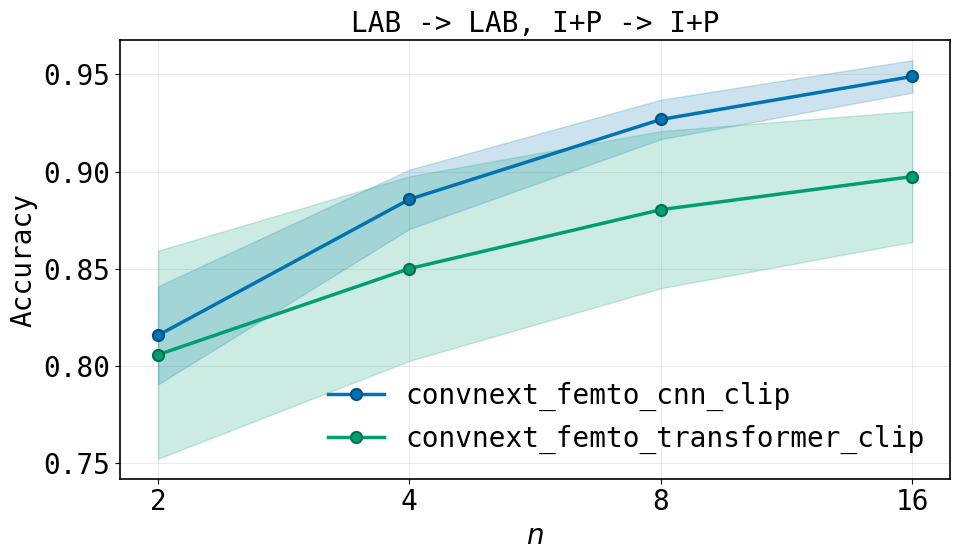

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configs
k = 3
n_vals = N[:]
folds = FOLDS[:] 
sims = SIMS[:]  
setup = "I+P - I+P"  # which setup to plot

# Label size
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans Mono",
        "font.size": 20,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        # 'legend.fontsize': 20,
        "figure.titlesize": 20,
        "axes.linewidth": 1.2,
    }
)

def darker(color, factor=0.7):
    """Return a darker shade of a Matplotlib-compatible color."""
    import matplotlib.colors as mcolors

    rgb = np.array(mcolors.to_rgb(color))
    return np.clip(rgb * factor, 0, 1)

# Adapted colourblind palette
colorblind = ["#0173B2", "#029E73", "#D55E00", "#CC78BC", "#ECE133", "#949494"]

# Create figures
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(True, which="major", linestyle="-", linewidth=0.75, alpha=0.25)
ax.set_axisbelow(True)

# Loop over models
for idx, name in enumerate(NAMES):
    color = colorblind[idx % len(colorblind)]
    edge_color = darker(color)

    accs = {n: [] for n in n_vals}
    for fold in tqdm(folds, desc=f"{name} folds"):
        for n in n_vals:
            sub = results[name][fold][n]
            for sim in sims:
                coder = create_coder(sub, sim, setup, k)
                true = coder.transform(sub[sim]["true"])
                pred = coder.transform(sub[sim]["pred"][k][setup])
                acc = accuracy_score(true, pred)
                accs[n].append(acc)

    # Compute mean ± std per n
    means = np.array([np.mean(accs[n]) for n in n_vals])
    stds = np.array([np.std(accs[n]) for n in n_vals])

    # Plot
    ax.plot(
        n_vals,
        means,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=8,
        markeredgewidth=1.5,
        markeredgecolor=edge_color,
        label=name,
        zorder=3,
    )

    ax.fill_between(n_vals, means - stds, means + stds, color=color, alpha=0.2, zorder=2)

# Set axis and labels
ax.set_xlabel(r"$n$")
ax.set_ylabel("Accuracy")
ax.set_xscale("log")
ax.set_xticks(n_vals)
ax.set_xticklabels(n_vals)
ax.minorticks_off()

# Add legend
handles, labels = ax.get_legend_handles_labels()

labels2 = ["_".join(label.split("_")[:4]) for label in labels]

ax.legend(
    handles,
    labels2,
    loc="lower right",
    ncol=1,
    frameon=False,
)

# Show and save (optional)
plt.title("LAB -> LAB, I+P -> I+P")
plt.tight_layout()
# plt.savefig("./results/figures/results_convnext_lab.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
